# S05 — Matplotlib: Visualising Physical Fields and Pulse Data

**Python for Applied Physics** | Master in Applied Physics  
**Prerequisites:** S01–S04

---

## Learning objectives

By the end of this session you will be able to:

- Use the object-oriented Matplotlib interface confidently
- Build 1D, multi-panel, 2D, 3D, and complex-field plots
- Construct 2D grids with `np.meshgrid` and understand its conventions
- Choose appropriate colormaps for physical data
- Produce publication-ready figures with correct sizing, fonts, and export format

---

## Session map

| Block | Topic | Cells |
|-------|-------|-------|
| 1 | Matplotlib architecture | 1–5 |
| 2 | 1D plots | 6–12 |
| 3 | Multiple panels | 13–17 |
| 4 | 2D plots + meshgrid | 18–25 |
| 5 | Contours and vector fields | 26–29 |
| 6 | 3D surface plots | 30–33 |
| 7 | Colormaps for complex fields | 34–37 |
| 8 | Publication quality | 38–41 |

In [3]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401 — registers 3D projection

print(f"NumPy      {np.__version__}")
print(f"Matplotlib {matplotlib.__version__}")

# Use inline backend for Jupyter
%matplotlib inline
plt.rcParams['figure.dpi'] = 100

NumPy      2.4.3
Matplotlib 3.10.8


---
## Block 1 — Matplotlib architecture

Matplotlib has two interfaces:

| Interface | Style | When to use |
|-----------|-------|-------------|
| **Stateful** (`plt.plot`) | MATLAB-like, implicit current axes | Quick interactive exploration |
| **Object-oriented** (`fig, ax = plt.subplots()`) | Explicit Figure and Axes objects | Scripts, functions, multi-panel figures |

**We use the OO interface throughout this course.** It is unambiguous, composable, and works correctly inside functions.

```
Figure
└── Axes  (one or more)
    ├── XAxis / YAxis
    ├── Title
    └── Artists  (Line2D, Collection, Text, …)
```

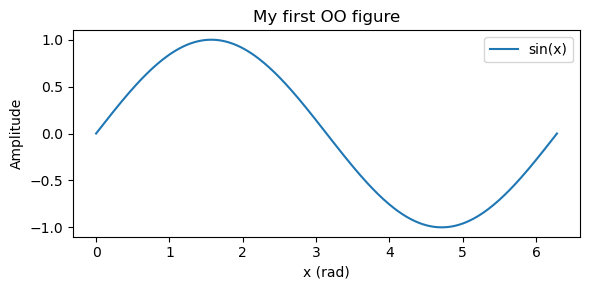

In [4]:
# --------------------------------------------------------------------------
# Anatomy of a Matplotlib figure
# --------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(6, 3))

x = np.linspace(0, 2 * np.pi, 256)
ax.plot(x, np.sin(x), label='sin(x)')

ax.set_xlabel('x (rad)')
ax.set_ylabel('Amplitude')
ax.set_title('My first OO figure')
ax.legend()

fig.tight_layout()
plt.show()

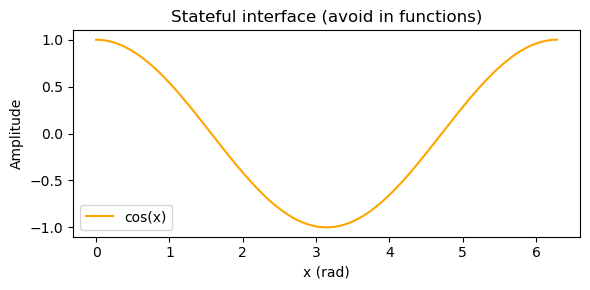

In [5]:
# --------------------------------------------------------------------------
# Stateful interface — for comparison only, avoid in production code
# --------------------------------------------------------------------------

plt.figure(figsize=(6, 3))
plt.plot(x, np.cos(x), color='orange', label='cos(x)')
plt.xlabel('x (rad)')
plt.ylabel('Amplitude')
plt.title('Stateful interface (avoid in functions)')
plt.legend()
plt.tight_layout()
plt.show()

# Both produce the same result here, but the OO version
# is explicit about which axes it is modifying.

💡 **Pro Tip — backends in Jupyter**

| Magic | Backend | Behaviour |
|-------|---------|----------|
| `%matplotlib inline` | Agg | Static PNG in cell output — fast, always works |
| `%matplotlib widget` | ipympl | Interactive: zoom, pan, rotate 3D — requires `pip install ipympl` |

For 3D surface plots you need `widget` to rotate interactively. Switch with `%matplotlib widget` at the top of the notebook; restart the kernel if you switch mid-session.

In [6]:
# --------------------------------------------------------------------------
# Shared physics setup — reused across all blocks
# --------------------------------------------------------------------------

# Beam parameters
w0  = 500e-6    # 500 µm beam radius
P   = 1.0       # W
λ   = 800e-9    # m
zR  = np.pi * w0**2 / λ   # Rayleigh range

# Pulse parameters
τ   = 100e-15   # 100 fs
N   = 2048
dt  = 5e-15
t   = (np.arange(N) - N // 2) * dt
E_t = np.exp(-t**2 / (2 * τ**2))      # Gaussian envelope
freq = np.fft.fftshift(np.fft.fftfreq(N, d=dt))
E_f  = np.fft.fftshift(np.fft.fft(E_t))
S    = np.abs(E_f)**2

print(f"Rayleigh range zR = {zR*100:.2f} cm")
print(f"Time window       = {t[0]*1e12:.1f} to {t[-1]*1e12:.1f} ps")

Rayleigh range zR = 98.17 cm
Time window       = -5.1 to 5.1 ps


---
## Block 2 — 1D plots

The workhorse of scientific plotting. Covers everything from a single line to overlaid curves with twin axes.

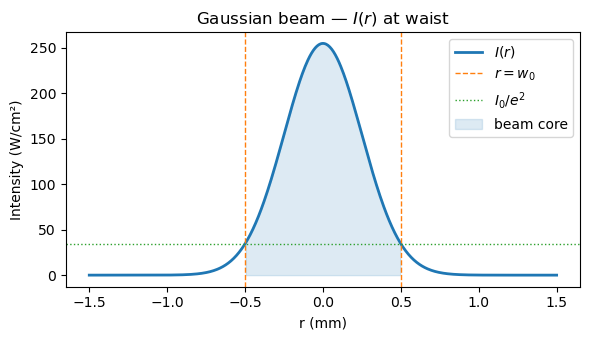

In [7]:
# --------------------------------------------------------------------------
# 🔬 Physics Insight — Gaussian beam intensity I(r)
# --------------------------------------------------------------------------

r   = np.linspace(-3 * w0, 3 * w0, 512)
I0  = 2 * P / (np.pi * w0**2)
I_r = I0 * np.exp(-2 * r**2 / w0**2)

fig, ax = plt.subplots(figsize=(6, 3.5))

ax.plot(r * 1e3, I_r / 1e4, color='C0', lw=2, label=r'$I(r)$')
ax.axvline( w0 * 1e3, color='C1', ls='--', lw=1, label=r'$r = w_0$')
ax.axvline(-w0 * 1e3, color='C1', ls='--', lw=1)
ax.axhline(I0 * np.exp(-2) / 1e4, color='C2', ls=':', lw=1, label=r'$I_0/e^2$')
ax.fill_between(r * 1e3, I_r / 1e4,
                where=np.abs(r) <= w0,
                alpha=0.15, color='C0', label='beam core')

ax.set_xlabel('r (mm)')
ax.set_ylabel(r'Intensity (W/cm²)')
ax.set_title(r'Gaussian beam — $I(r)$ at waist')
ax.legend()
fig.tight_layout()
plt.show()

In [ ]:
# --------------------------------------------------------------------------
# Line styles, colours, markers
# --------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(6, 3))

styles = [
    dict(color='C0', lw=2,   ls='-',  label='solid'),
    dict(color='C1', lw=1.5, ls='--', label='dashed'),
    dict(color='C2', lw=1.5, ls=':',  label='dotted'),
    dict(color='C3', lw=0,   marker='o', ms=4, label='markers'),
]

x_s = np.linspace(0, 2*np.pi, 60)
for i, kw in enumerate(styles):
    ax.plot(x_s, np.sin(x_s + i * 0.4), **kw)

ax.set_xlabel('x')
ax.legend(ncol=2)
fig.tight_layout()
plt.show()

In [ ]:
# --------------------------------------------------------------------------
# Twin axes — intensity and accumulated phase on the same plot
# --------------------------------------------------------------------------

# Simulate a chirped pulse: intensity envelope + quadratic phase
GDD     = 300e-30   # 300 fs²
I_t     = np.abs(E_t)**2
# Phase of chirped field (baseband)
ω_axis  = 2 * np.pi * freq
E_f_gdd = E_f * np.exp(0.5j * GDD * ω_axis**2)
E_chirp = np.fft.ifft(np.fft.ifftshift(E_f_gdd))
φ_t     = np.unwrap(np.angle(E_chirp))

fig, ax1 = plt.subplots(figsize=(7, 3.5))
ax2 = ax1.twinx()   # shares x-axis, independent y-axis

ax1.plot(t * 1e15, np.abs(E_chirp)**2, color='C0', lw=2, label='Intensity')
ax2.plot(t * 1e15, φ_t,                color='C1', lw=1.5, ls='--', label='Phase')

ax1.set_xlabel('Time (fs)')
ax1.set_ylabel('Intensity (a.u.)', color='C0')
ax2.set_ylabel('Phase (rad)',      color='C1')
ax1.set_xlim(-600, 600)

# Merge legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
ax1.set_title('Chirped pulse — intensity and phase')
fig.tight_layout()
plt.show()

In [ ]:
# --------------------------------------------------------------------------
# Logarithmic axes — useful for gain spectra, extinction curves
# --------------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

# semilogy: linear x, log y
z_ax = np.linspace(-5 * zR, 5 * zR, 256)
w_z  = w0 * np.sqrt(1 + (z_ax / zR)**2)
axes[0].semilogy(z_ax * 100, w_z * 1e3)
axes[0].set_xlabel('z (cm)')
axes[0].set_ylabel('w(z) (mm)')
axes[0].set_title('semilogy — beam radius')

# loglog: both axes logarithmic
f_plot = freq[freq > 0]
S_plot = S[freq > 0]
axes[1].loglog(f_plot / 1e12, S_plot / S_plot.max())
axes[1].set_xlabel('Frequency (THz)')
axes[1].set_ylabel('PSD (norm.)')
axes[1].set_title('loglog — pulse spectrum')

fig.tight_layout()
plt.show()

In [ ]:
# --------------------------------------------------------------------------
# Error bars — shot-to-shot energy fluctuations
# --------------------------------------------------------------------------

rng      = np.random.default_rng(42)
shots    = np.arange(1, 11)
energies = 50 + rng.normal(0, 2, size=10)   # µJ, ~4% fluctuation
errors   = rng.uniform(0.5, 1.5, size=10)

fig, ax = plt.subplots(figsize=(6, 3))
ax.errorbar(shots, energies, yerr=errors,
            fmt='o', capsize=4, color='C0', label='pulse energy')
ax.axhline(energies.mean(), ls='--', color='C1', label=f'mean = {energies.mean():.1f} µJ')
ax.set_xlabel('Shot number')
ax.set_ylabel('Energy (µJ)')
ax.set_title('Shot-to-shot energy stability')
ax.legend()
fig.tight_layout()
plt.show()

---
## Block 3 — Multiple panels

`plt.subplots(nrows, ncols)` returns a Figure and an array of Axes.  
For non-uniform layouts use `GridSpec`.

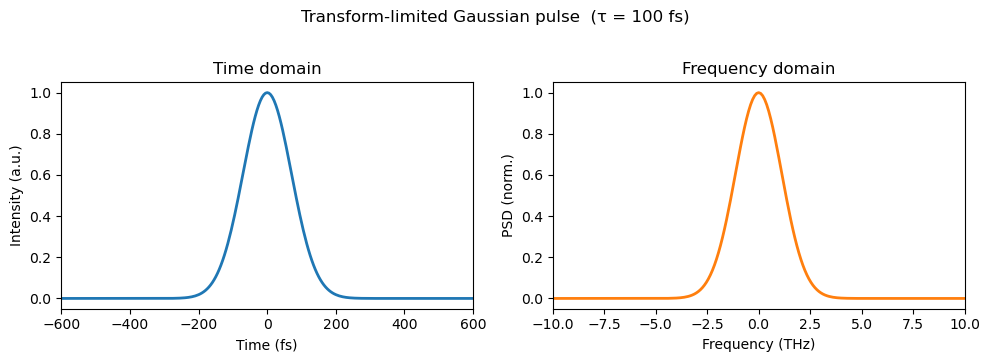

In [8]:
# --------------------------------------------------------------------------
# 🔬 Physics Insight — pulse in time + spectrum side by side
# --------------------------------------------------------------------------

fig, (ax_t, ax_f) = plt.subplots(1, 2, figsize=(10, 3.5))

# Time domain
ax_t.plot(t * 1e15, np.abs(E_t)**2, color='C0', lw=2)
ax_t.set_xlabel('Time (fs)')
ax_t.set_ylabel('Intensity (a.u.)')
ax_t.set_title('Time domain')
ax_t.set_xlim(-600, 600)

# Frequency domain
ax_f.plot(freq / 1e12, S / S.max(), color='C1', lw=2)
ax_f.set_xlabel('Frequency (THz)')
ax_f.set_ylabel('PSD (norm.)')
ax_f.set_title('Frequency domain')
ax_f.set_xlim(-10, 10)

fig.suptitle('Transform-limited Gaussian pulse  (τ = 100 fs)', y=1.02)
fig.tight_layout()
plt.show()

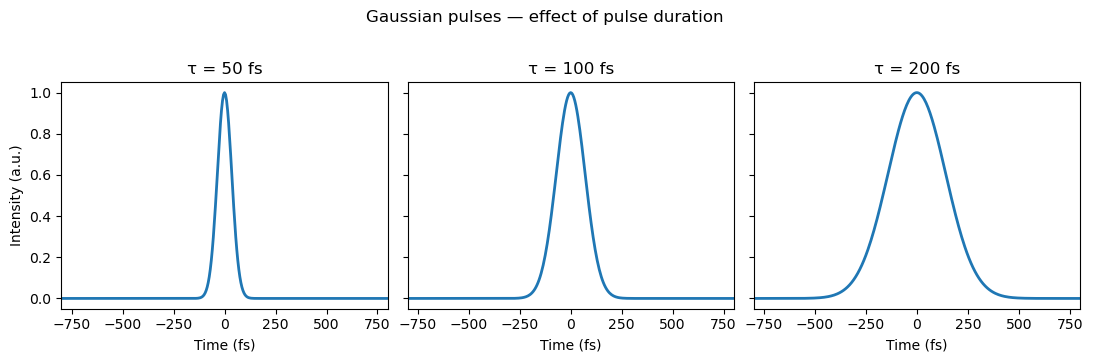

In [9]:
# --------------------------------------------------------------------------
# sharex / sharey — keep axis ranges synchronised
# --------------------------------------------------------------------------

τ_vals = [50e-15, 100e-15, 200e-15]
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5), sharey=True)

for ax, τ_i in zip(axes, τ_vals):
    E_i = np.exp(-t**2 / (2 * τ_i**2))
    ax.plot(t * 1e15, E_i**2, lw=2)
    ax.set_xlabel('Time (fs)')
    ax.set_title(f'τ = {τ_i*1e15:.0f} fs')
    ax.set_xlim(-800, 800)

axes[0].set_ylabel('Intensity (a.u.)')
fig.suptitle('Gaussian pulses — effect of pulse duration', y=1.02)
fig.tight_layout()
plt.show()

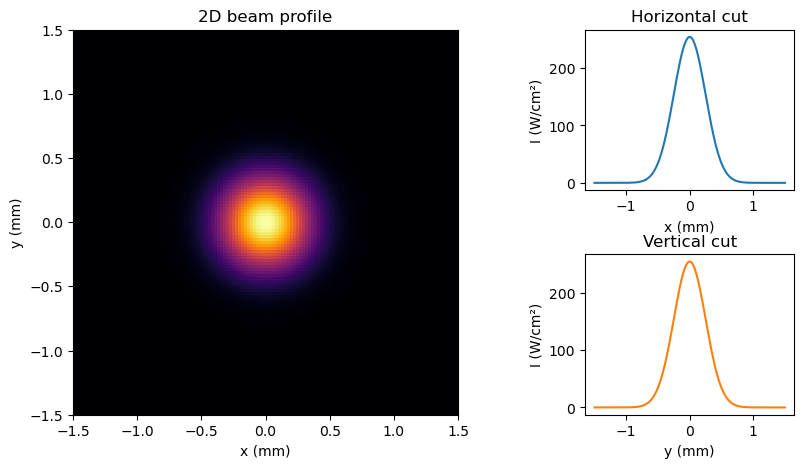

In [10]:
# --------------------------------------------------------------------------
# GridSpec — non-uniform panel layouts
# --------------------------------------------------------------------------

fig = plt.figure(figsize=(10, 5))
gs  = GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

ax_main  = fig.add_subplot(gs[:, 0:2])   # spans both rows, cols 0–1
ax_top   = fig.add_subplot(gs[0, 2])     # top right
ax_bot   = fig.add_subplot(gs[1, 2])     # bottom right

# Main: 2D beam (preview — proper 2D plots in Block 4)
x_g = np.linspace(-3*w0, 3*w0, 128)
X_g, Y_g = np.meshgrid(x_g, x_g)
I_2d = (2*P/(np.pi*w0**2)) * np.exp(-2*(X_g**2+Y_g**2)/w0**2)
ax_main.imshow(I_2d / 1e4, origin='lower',
               extent=[-3*w0*1e3, 3*w0*1e3, -3*w0*1e3, 3*w0*1e3],
               cmap='inferno')
ax_main.set_xlabel('x (mm)')
ax_main.set_ylabel('y (mm)')
ax_main.set_title('2D beam profile')

# Top right: horizontal cross-section
ax_top.plot(x_g * 1e3, I_2d[64, :] / 1e4, color='C0')
ax_top.set_xlabel('x (mm)')
ax_top.set_ylabel('I (W/cm²)')
ax_top.set_title('Horizontal cut')

# Bottom right: vertical cross-section
ax_bot.plot(x_g * 1e3, I_2d[:, 64] / 1e4, color='C1')
ax_bot.set_xlabel('y (mm)')
ax_bot.set_ylabel('I (W/cm²)')
ax_bot.set_title('Vertical cut')

plt.show()

PNG: 19.7 kB
PDF: 10.1 kB
SVG: 19.6 kB


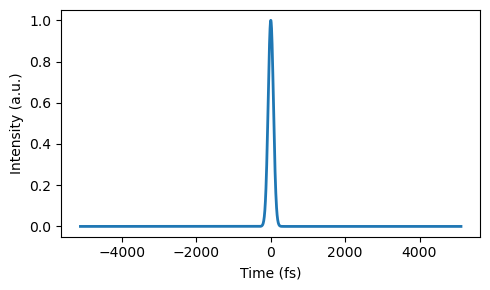

In [11]:
# --------------------------------------------------------------------------
# fig.savefig — export to PNG, PDF, SVG
# --------------------------------------------------------------------------

import tempfile, os

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(t * 1e15, np.abs(E_t)**2, lw=2)
ax.set_xlabel('Time (fs)')
ax.set_ylabel('Intensity (a.u.)')
fig.tight_layout()

with tempfile.TemporaryDirectory() as tmp:
    for fmt in ['png', 'pdf', 'svg']:
        path = os.path.join(tmp, f'pulse.{fmt}')
        fig.savefig(path, dpi=150, bbox_inches='tight')
        size = os.path.getsize(path)
        print(f"{fmt.upper()}: {size/1024:.1f} kB")

plt.show()
# PDF and SVG are vector formats — use them for journal figures

---
## Block 4 — 2D plots + `np.meshgrid`

Before plotting 2D fields we need to build 2D coordinate grids.  
`np.meshgrid` is the standard tool for this.

In [12]:
# --------------------------------------------------------------------------
# np.meshgrid — building 2D coordinate grids
# --------------------------------------------------------------------------

x = np.linspace(-2, 2, 5)
y = np.linspace(-1, 1, 3)

# Default indexing='xy'  →  X varies along columns, Y along rows
X, Y = np.meshgrid(x, y)
print(f"x shape : {x.shape}   y shape : {y.shape}")
print(f"X shape : {X.shape}   (Ny × Nx = {len(y)} × {len(x)})")
print(f"Y shape : {Y.shape}")
print(f"\nX:\n{X}")
print(f"\nY:\n{Y}")

x shape : (5,)   y shape : (3,)
X shape : (3, 5)   (Ny × Nx = 3 × 5)
Y shape : (3, 5)

X:
[[-2. -1.  0.  1.  2.]
 [-2. -1.  0.  1.  2.]
 [-2. -1.  0.  1.  2.]]

Y:
[[-1. -1. -1. -1. -1.]
 [ 0.  0.  0.  0.  0.]
 [ 1.  1.  1.  1.  1.]]


⚠️ **Common Pitfall — `indexing='xy'` vs `indexing='ij'`**

| | `indexing='xy'` (default) | `indexing='ij'` |
|-|--------------------------|------------------|
| X shape | `(Ny, Nx)` | `(Nx, Ny)` |
| Y shape | `(Ny, Nx)` | `(Nx, Ny)` |
| Row index | y | x |
| Matches `imshow` | ✓ | ✗ |
| Matches math convention | ✗ | ✓ |

```python
X, Y = np.meshgrid(x, y)              # default: Z[row, col] = Z[y_idx, x_idx]
X, Y = np.meshgrid(x, y, indexing='ij')  # matrix: Z[i, j] = Z[x_idx, y_idx]
```

**Rule:** use `indexing='xy'` (default) when passing to `imshow` or `pcolormesh`.  
Use `indexing='ij'` when indexing as `Z[i_x, i_y]` in mathematical notation.

Broadcasting (`X = x[np.newaxis, :], Y = y[:, np.newaxis]`) is equivalent to `indexing='xy'` and avoids copying data.

In [13]:
# --------------------------------------------------------------------------
# 🔬 Physics Insight — 2D Gaussian beam intensity
# --------------------------------------------------------------------------

N_2d = 256
x_2d = np.linspace(-3 * w0, 3 * w0, N_2d)
y_2d = np.linspace(-3 * w0, 3 * w0, N_2d)

# Build grid and compute field
X2, Y2 = np.meshgrid(x_2d, y_2d)   # both shape (N_2d, N_2d)
I_2d   = (2*P / (np.pi*w0**2)) * np.exp(-2 * (X2**2 + Y2**2) / w0**2)

print(f"Grid shape : {X2.shape}")
print(f"I_2d shape : {I_2d.shape}")
print(f"Peak       : {I_2d.max()/1e4:.2f} W/cm²")

Grid shape : (256, 256)
I_2d shape : (256, 256)
Peak       : 254.51 W/cm²


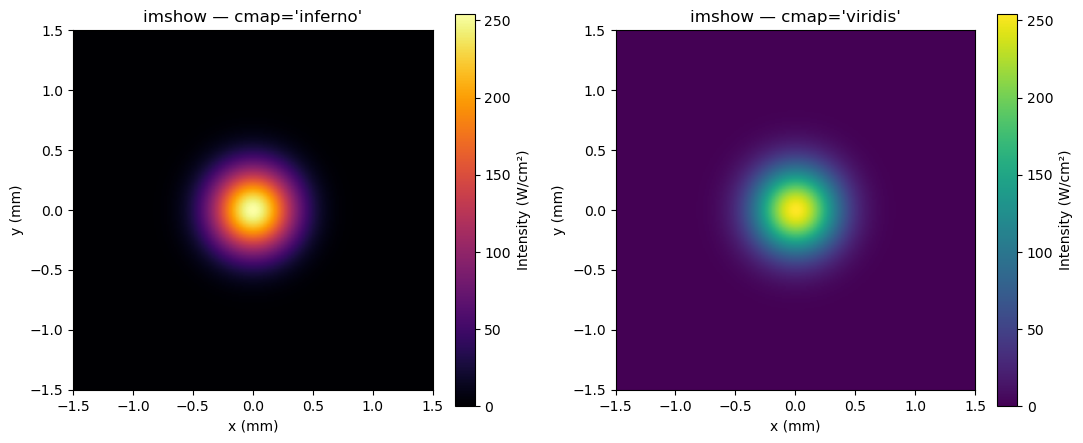

In [14]:
# --------------------------------------------------------------------------
# ax.imshow — raster image display
# --------------------------------------------------------------------------

extent = [
    x_2d[0]*1e3, x_2d[-1]*1e3,   # x: left, right (mm)
    y_2d[0]*1e3, y_2d[-1]*1e3,   # y: bottom, top (mm)
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, cmap in zip(axes, ['inferno', 'viridis']):
    im = ax.imshow(
        I_2d / 1e4,
        origin='lower',      # row 0 at bottom (physics convention)
        extent=extent,
        aspect='equal',
        cmap=cmap,
    )
    fig.colorbar(im, ax=ax, label='Intensity (W/cm²)')
    ax.set_xlabel('x (mm)')
    ax.set_ylabel('y (mm)')
    ax.set_title(f'imshow — cmap={cmap!r}')

fig.tight_layout()
plt.show()

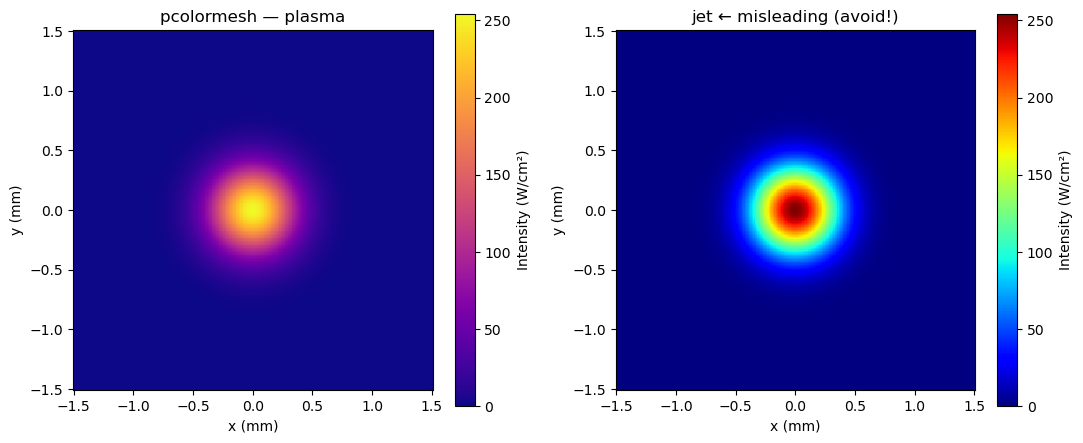

In [15]:
# --------------------------------------------------------------------------
# ax.pcolormesh — preferred for non-uniform grids
# --------------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# pcolormesh takes the X, Y arrays directly
im0 = axes[0].pcolormesh(X2 * 1e3, Y2 * 1e3, I_2d / 1e4,
                          cmap='plasma', shading='auto')
fig.colorbar(im0, ax=axes[0], label='Intensity (W/cm²)')
axes[0].set_xlabel('x (mm)')
axes[0].set_ylabel('y (mm)')
axes[0].set_title('pcolormesh — plasma')
axes[0].set_aspect('equal')

# ⚠️ Pitfall: jet colormap
im1 = axes[1].pcolormesh(X2 * 1e3, Y2 * 1e3, I_2d / 1e4,
                          cmap='jet', shading='auto')
fig.colorbar(im1, ax=axes[1], label='Intensity (W/cm²)')
axes[1].set_xlabel('x (mm)')
axes[1].set_ylabel('y (mm)')
axes[1].set_title('jet ← misleading (avoid!)')
axes[1].set_aspect('equal')

fig.tight_layout()
plt.show()

⚠️ **Common Pitfall — the `jet` colormap**

`jet` is perceptually non-uniform: equal steps in data value produce unequal steps in perceived brightness. This creates **false features** — bright bands that do not correspond to real data.

| Use case | Recommended colormap |
|----------|---------------------|
| Sequential (0 → max) | `viridis`, `plasma`, `inferno` |
| Diverging (negative → 0 → positive) | `RdBu`, `seismic`, `bwr` |
| Phase / cyclic | `hsv`, `twilight` |
| Greyscale print | `viridis`, `gray` |

All recommended colormaps are perceptually uniform and print correctly in greyscale.

---
## Block 5 — Contours and vector fields

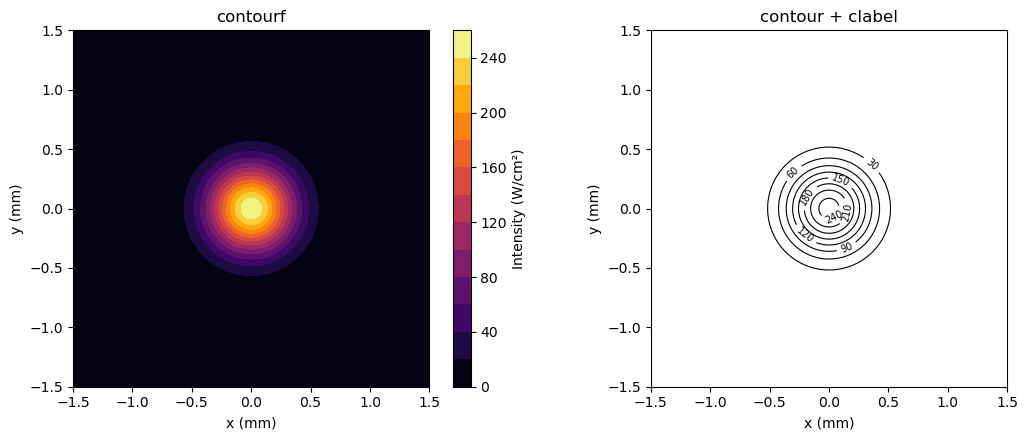

In [16]:
# --------------------------------------------------------------------------
# ax.contourf + ax.contour + ax.clabel
# --------------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Filled contours
cf = axes[0].contourf(X2 * 1e3, Y2 * 1e3, I_2d / 1e4,
                       levels=15, cmap='inferno')
fig.colorbar(cf, ax=axes[0], label='Intensity (W/cm²)')
axes[0].set_xlabel('x (mm)')
axes[0].set_ylabel('y (mm)')
axes[0].set_title('contourf')
axes[0].set_aspect('equal')

# Overlay contour lines with labels
cs = axes[1].contour(X2 * 1e3, Y2 * 1e3, I_2d / 1e4,
                      levels=8, colors='k', linewidths=0.8)
axes[1].clabel(cs, fmt='%.0f', fontsize=7)
axes[1].set_xlabel('x (mm)')
axes[1].set_ylabel('y (mm)')
axes[1].set_title('contour + clabel')
axes[1].set_aspect('equal')

fig.tight_layout()
plt.show()

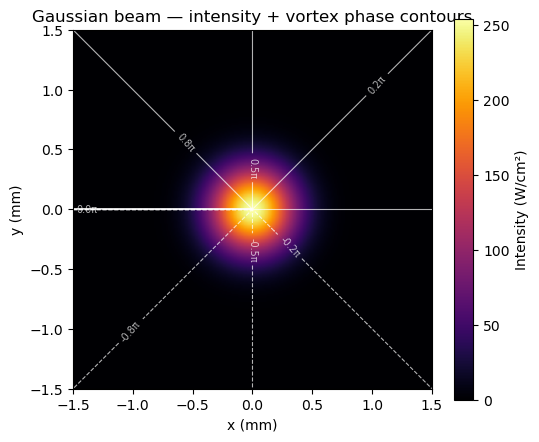

In [17]:
# --------------------------------------------------------------------------
# 🔬 Physics Insight — intensity + phase contours overlaid
# --------------------------------------------------------------------------

# Phase of a Gaussian beam with a vortex charge l=1
# φ(x,y) = arctan(y/x)  — azimuthal phase
φ_vortex = np.arctan2(Y2, X2)   # range [-π, π]

fig, ax = plt.subplots(figsize=(5.5, 5))

im = ax.imshow(I_2d / 1e4, origin='lower', extent=[
    x_2d[0]*1e3, x_2d[-1]*1e3, y_2d[0]*1e3, y_2d[-1]*1e3],
    cmap='inferno', aspect='equal')
fig.colorbar(im, ax=ax, label='Intensity (W/cm²)', shrink=0.85)

# Phase contours in white
cs = ax.contour(X2*1e3, Y2*1e3, φ_vortex,
                levels=np.linspace(-np.pi, np.pi, 9),
                colors='white', linewidths=0.8, alpha=0.7)
ax.clabel(cs, fmt=lambda v: f'{v/np.pi:.1f}π', fontsize=7, colors='white')

ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_title('Gaussian beam — intensity + vortex phase contours')
fig.tight_layout()
plt.show()

---
## Block 6 — 3D surface plots

`Axes3D` is Matplotlib's 3D toolkit. It uses the same meshgrid arrays as 2D plots.

💡 **Pro Tip:** For publication figures, 3D surface plots are rarely accepted by journals. Prefer a 2D `imshow` + a 1D cross-section. Use 3D plots for presentations and exploratory work.

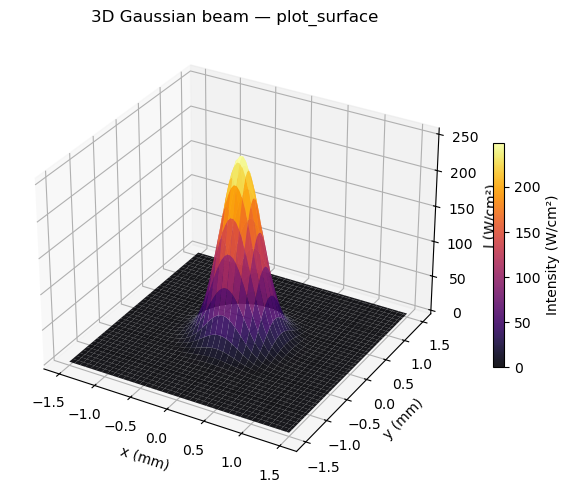

In [28]:
# --------------------------------------------------------------------------
# plot_surface — 3D Gaussian beam intensity
# --------------------------------------------------------------------------

# Coarser grid for 3D (rendering is slow at full resolution)
N_3d  = 80
x_3d  = np.linspace(-3 * w0, 3 * w0, N_3d)
X3, Y3 = np.meshgrid(x_3d, x_3d)
I_3d   = (2*P/(np.pi*w0**2)) * np.exp(-2*(X3**2+Y3**2)/w0**2)

fig = plt.figure(figsize=(7, 5))
ax  = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    X3 * 1e3, Y3 * 1e3, I_3d / 1e4,
    cmap='inferno',
    alpha=0.9,
    linewidth=0,
    antialiased=True,
)
fig.colorbar(surf, ax=ax, shrink=0.5, label='Intensity (W/cm²)')

ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_zlabel('I (W/cm²)')
ax.set_title('3D Gaussian beam — plot_surface')
ax.view_init(elev=30, azim=-60)   # set viewing angle

fig.tight_layout()
plt.show()

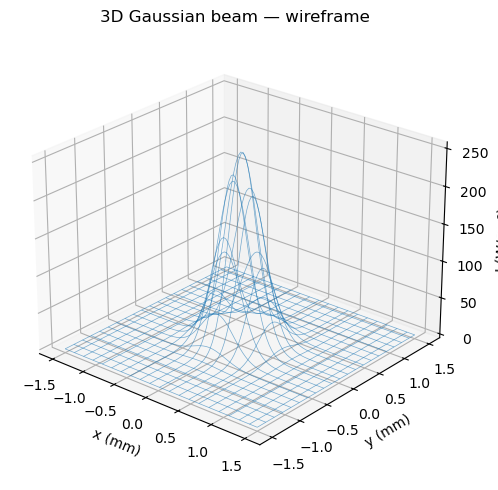

In [29]:
# --------------------------------------------------------------------------
# plot_wireframe — useful when transparency matters
# --------------------------------------------------------------------------

fig = plt.figure(figsize=(7, 5))
ax  = fig.add_subplot(111, projection='3d')

ax.plot_wireframe(
    X3 * 1e3, Y3 * 1e3, I_3d / 1e4,
    rstride=4, cstride=4,   # sample every 4 rows/cols
    color='C0', linewidth=0.5, alpha=0.6,
)
ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_zlabel('I (W/cm²)')
ax.set_title('3D Gaussian beam — wireframe')
ax.view_init(elev=25, azim=-50)

fig.tight_layout()
plt.show()

In [ ]:
# ⚡ Try It — LG₀₁ ring mode surface
#
# Build the 3D surface of an LG₀₁ intensity:
#   I(r) = I₀ · (r/w)² · exp(-2r²/w²)
# Adjust view_init to find the most informative angle.

# YOUR CODE HERE

# Solution (hidden)
# R2_3d = X3**2 + Y3**2
# I_LG  = (2*P/(np.pi*w0**2)) * (np.sqrt(R2_3d)/w0)**2 * np.exp(-2*R2_3d/w0**2)
# fig = plt.figure(figsize=(7, 5))
# ax  = fig.add_subplot(111, projection='3d')
# ax.plot_surface(X3*1e3, Y3*1e3, I_LG/1e4, cmap='plasma', alpha=0.9, linewidth=0)
# ax.view_init(elev=35, azim=-45)
# plt.show()

---
## Block 7 — Colormaps for complex fields

A complex field $E(x,y) = A(x,y)\,e^{i\phi(x,y)}$ has both amplitude and phase.  
The standard representation: **amplitude → brightness, phase → hue** (HSV encoding).

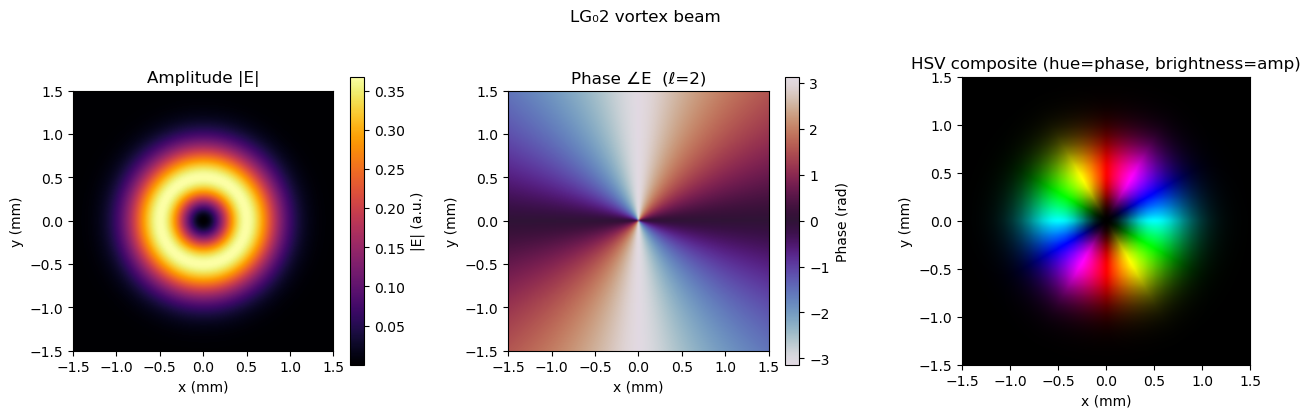

In [30]:
# --------------------------------------------------------------------------
# 🔬 Physics Insight — phase map of a vortex beam
# --------------------------------------------------------------------------

# LG₀ℓ field with topological charge ℓ=2
ℓ    = 2
R2   = X2**2 + Y2**2
R    = np.sqrt(R2)
E_LG = (R / w0)**ℓ * np.exp(-R2 / w0**2) * np.exp(1j * ℓ * np.arctan2(Y2, X2))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Amplitude
im0 = axes[0].imshow(np.abs(E_LG), origin='lower',
                      extent=[x_2d[0]*1e3, x_2d[-1]*1e3]*2,
                      cmap='inferno', aspect='equal')
fig.colorbar(im0, ax=axes[0], label='|E| (a.u.)')
axes[0].set_title('Amplitude |E|')

# Phase
im1 = axes[1].imshow(np.angle(E_LG), origin='lower',
                      extent=[x_2d[0]*1e3, x_2d[-1]*1e3]*2,
                      cmap='twilight', vmin=-np.pi, vmax=np.pi,
                      aspect='equal')
fig.colorbar(im1, ax=axes[1], label='Phase (rad)')
axes[1].set_title(f'Phase ∠E  (ℓ={ℓ})')

# HSV composite: hue = phase, value = amplitude
import matplotlib.colors as mcolors
phase_norm = (np.angle(E_LG) + np.pi) / (2 * np.pi)   # [0, 1]
amp_norm   = np.abs(E_LG) / np.abs(E_LG).max()          # [0, 1]
# Stack H, S, V channels
hsv_image  = np.stack([phase_norm, np.ones_like(amp_norm), amp_norm], axis=-1)
rgb_image  = mcolors.hsv_to_rgb(hsv_image)

axes[2].imshow(rgb_image, origin='lower',
               extent=[x_2d[0]*1e3, x_2d[-1]*1e3]*2,
               aspect='equal')
axes[2].set_title('HSV composite (hue=phase, brightness=amp)')

for ax in axes:
    ax.set_xlabel('x (mm)')
    ax.set_ylabel('y (mm)')

fig.suptitle(f'LG₀{ℓ} vortex beam', y=1.02)
fig.tight_layout()
plt.show()

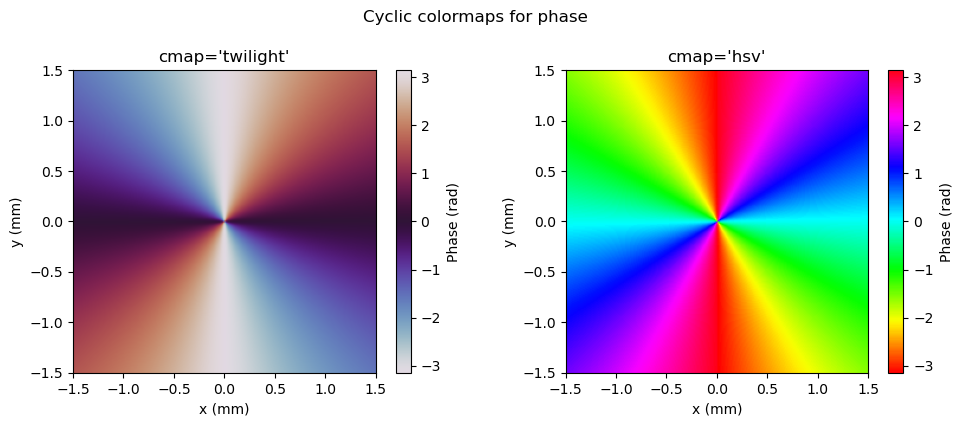

In [31]:
# --------------------------------------------------------------------------
# Cyclic colormap comparison — twilight vs hsv
# --------------------------------------------------------------------------

phase_map = np.angle(E_LG)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, cmap in zip(axes, ['twilight', 'hsv']):
    im = ax.imshow(phase_map, origin='lower',
                   extent=[x_2d[0]*1e3, x_2d[-1]*1e3]*2,
                   cmap=cmap, vmin=-np.pi, vmax=np.pi,
                   aspect='equal')
    fig.colorbar(im, ax=ax, label='Phase (rad)')
    ax.set_title(f'cmap={cmap!r}')
    ax.set_xlabel('x (mm)')
    ax.set_ylabel('y (mm)')

# twilight is perceptually uniform; hsv is not but is traditional for phase
fig.suptitle('Cyclic colormaps for phase', y=1.02)
fig.tight_layout()
plt.show()

---
## Block 8 — Publication quality

Journal figures have strict requirements: specific size (single/double column), font sizes ≥ 8 pt, vector formats. Matplotlib can produce them directly.

In [32]:
# --------------------------------------------------------------------------
# rcParams — global style settings
# --------------------------------------------------------------------------

# Save current defaults
original_rcParams = plt.rcParams.copy()

# Publication style
plt.rcParams.update({
    'font.size':        9,
    'axes.labelsize':   9,
    'axes.titlesize':  10,
    'legend.fontsize':  8,
    'xtick.labelsize':  8,
    'ytick.labelsize':  8,
    'lines.linewidth':  1.5,
    'axes.linewidth':   0.8,
    'xtick.major.width':0.8,
    'ytick.major.width':0.8,
    'font.family':     'sans-serif',
    'figure.dpi':       150,
})

print("rcParams updated for publication style")

rcParams updated for publication style


Saved PDF: 17.7 kB


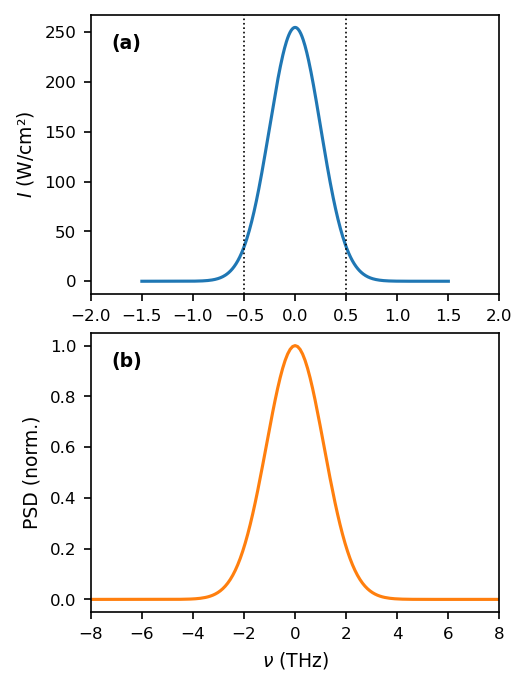

In [33]:
# --------------------------------------------------------------------------
# Publication-ready figure — single-column width (8.6 cm = 3.39 in)
# --------------------------------------------------------------------------

fig, axes = plt.subplots(2, 1, figsize=(3.39, 4.5), sharex=False)

# Panel (a): beam profile
axes[0].plot(r * 1e3, I_r / 1e4, color='C0')
axes[0].axvline( w0*1e3, color='k', ls=':', lw=0.8)
axes[0].axvline(-w0*1e3, color='k', ls=':', lw=0.8)
axes[0].set_ylabel(r'$I$ (W/cm²)')
axes[0].set_xlim(-2, 2)
axes[0].text(0.05, 0.88, '(a)', transform=axes[0].transAxes, fontweight='bold')

# Panel (b): pulse spectrum
axes[1].plot(freq / 1e12, S / S.max(), color='C1')
axes[1].set_xlabel(r'$\nu$ (THz)')
axes[1].set_ylabel('PSD (norm.)')
axes[1].set_xlim(-8, 8)
axes[1].text(0.05, 0.88, '(b)', transform=axes[1].transAxes, fontweight='bold')

fig.tight_layout(pad=0.5)

import tempfile, os
with tempfile.TemporaryDirectory() as tmp:
    path_pdf = os.path.join(tmp, 'figure1.pdf')
    fig.savefig(path_pdf, bbox_inches='tight')
    print(f"Saved PDF: {os.path.getsize(path_pdf)/1024:.1f} kB")

plt.show()

# Restore defaults
plt.rcParams.update(original_rcParams)

Available styles: ['ggplot', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid']


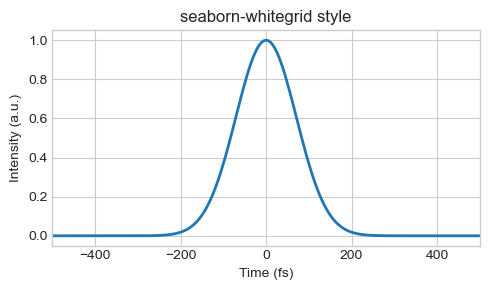

In [34]:
# --------------------------------------------------------------------------
# Style sheets — predefined sets of rcParams
# --------------------------------------------------------------------------

print("Available styles:", [s for s in plt.style.available if 'science' in s or 'seaborn' in s or 'ggplot' in s])

# Use a style contextually (does not change global state)
with plt.style.context('seaborn-v0_8-whitegrid'):
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.plot(t * 1e15, np.abs(E_t)**2, lw=2)
    ax.set_xlabel('Time (fs)')
    ax.set_ylabel('Intensity (a.u.)')
    ax.set_title('seaborn-whitegrid style')
    ax.set_xlim(-500, 500)
    fig.tight_layout()
    plt.show()

---
## Summary

| Task | Key calls |
|------|-----------|
| Create figure | `fig, ax = plt.subplots(nrows, ncols, figsize=, sharex=, sharey=)` |
| 1D plot | `ax.plot`, `ax.errorbar`, `ax.semilogy`, `ax.loglog` |
| Annotations | `ax.axvline`, `ax.axhline`, `ax.fill_between`, `ax.text` |
| Twin axes | `ax2 = ax.twinx()` |
| Non-uniform layout | `GridSpec(nrows, ncols)`, `fig.add_subplot(gs[...])` |
| 2D grid | `X, Y = np.meshgrid(x, y)` — default `indexing='xy'` |
| 2D raster | `ax.imshow(..., origin='lower', extent=, cmap=)` |
| 2D mesh | `ax.pcolormesh(X, Y, Z, shading='auto')` |
| Colorbar | `fig.colorbar(im, ax=ax, label=)` |
| Contours | `ax.contourf`, `ax.contour`, `ax.clabel` |
| Vectors | `ax.quiver(X, Y, U, V)` |
| 3D surface | `ax.plot_surface(X, Y, Z, cmap=)` — `projection='3d'` |
| Wireframe | `ax.plot_wireframe(X, Y, Z, rstride=, cstride=)` |
| Complex field | HSV encoding: `mcolors.hsv_to_rgb(np.stack([phase, sat, amp], axis=-1))` |
| Save | `fig.savefig(path, bbox_inches='tight', dpi=)` |
| Global style | `plt.rcParams.update({...})` or `plt.style.context(name)` |

**Next: S06 — SciPy, Pandas & Serialisation**